**I302 - Aprendizaje Automático y Aprendizaje Profundo**

<h1 style="text-align: center;"><strong>Trabajo Práctico 3: Redes Neuronales</strong></h1>

*Agustín A. Pereyra*

---

El presente trabajo tiene el objetivo de implementar y estudiar diferentes modelo de redes neuronales ...

## 1. Análisis y Preprocesamiento de Datos

In [16]:
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np
import pandas as pd
import seaborn as sbn

from src.utils import CLASSES_LABELS
from src.models import NN
from src.plots import loss_history, compare_metrics, compare_confusion_matrix

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [17]:
X_raw = np.load('data/X_images.npy')
y_raw = np.load('data/y_images.npy')

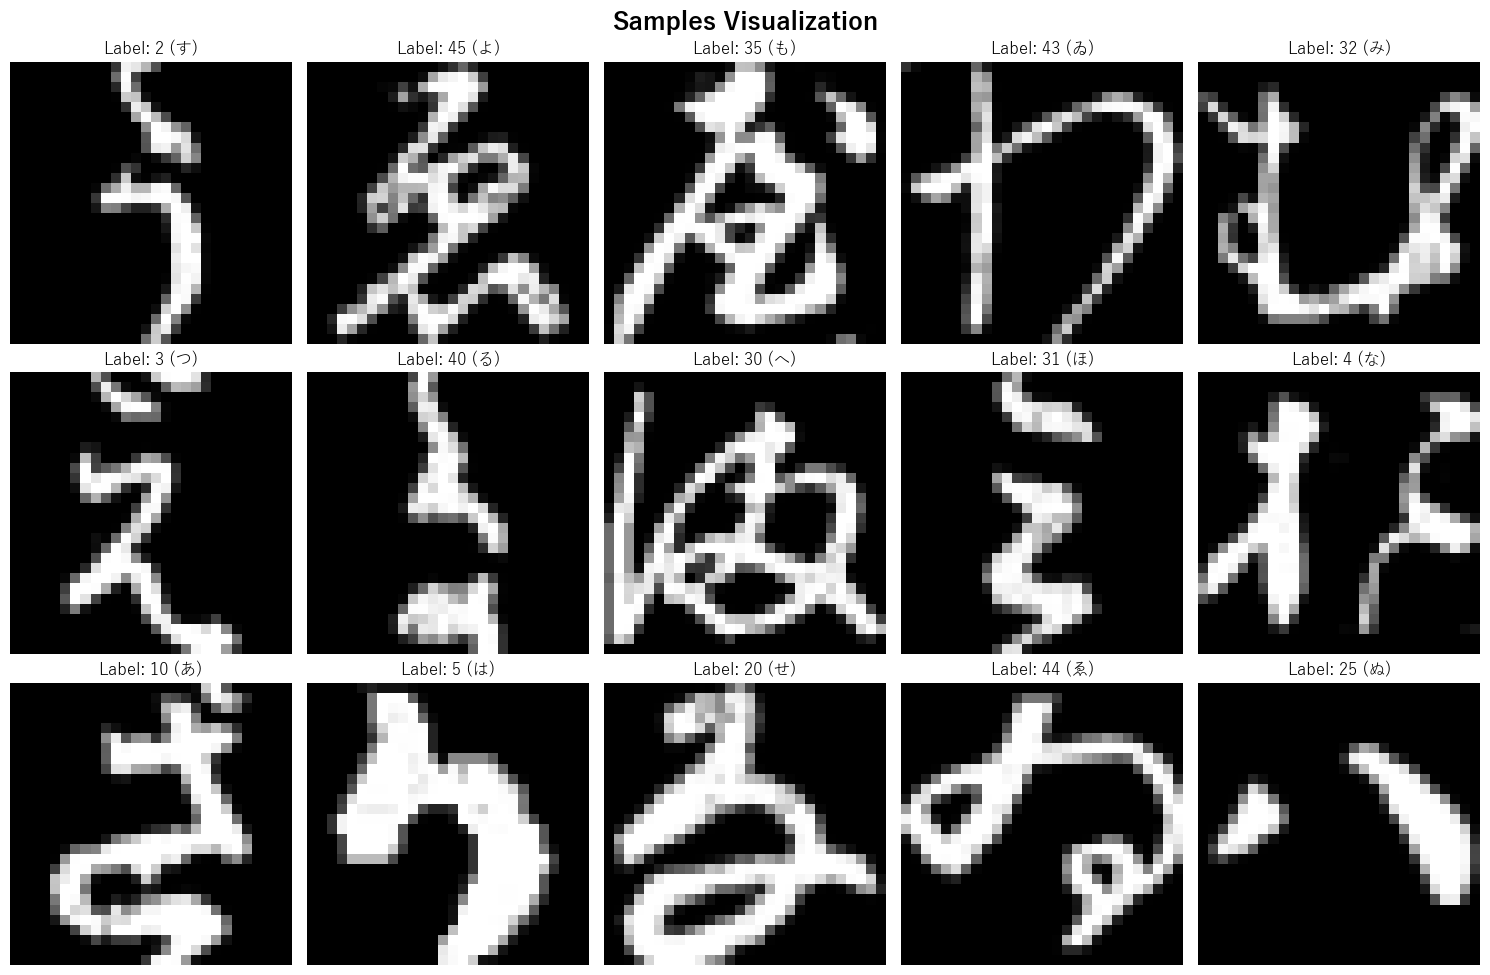

In [18]:
plt.rcParams['font.family'] = 'Yu Gothic' # fuente que contenga caracteres japoneses
fig, axes = plt.subplots(3, 5, figsize=(15, 10))
axes = axes.flatten()
for i in range(axes.size):
    idx = np.random.randint(0, X_raw.shape[0])
    img = X_raw[idx].reshape(28, 28)
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f'Label: {y_raw[idx]} ({CLASSES_LABELS[y_raw[idx]]})')
    axes[i].axis('off')
plt.suptitle('Samples Visualization', fontweight='bold', fontsize=18)
plt.tight_layout()
plt.show()

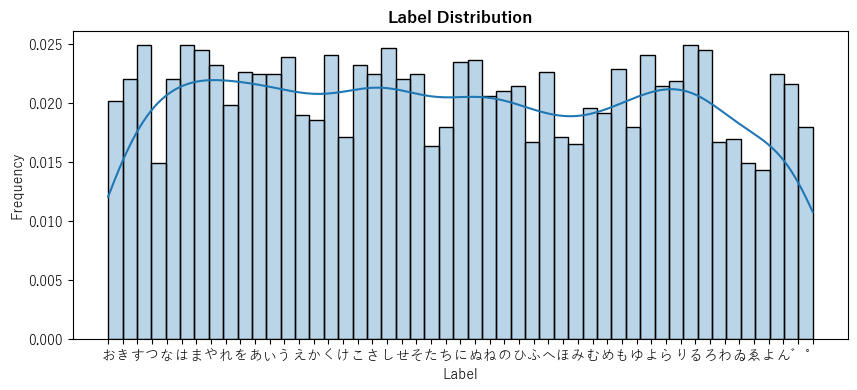

In [19]:
fig = plt.figure(figsize=(10,4))
sbn.histplot(
    y_raw,
    stat='density',
    alpha=0.3,
    kde=True,
    bins=49
	)
plt.xticks(range(49), CLASSES_LABELS)
plt.xlabel('Label')
plt.ylabel('Frequency')
plt.title('Label Distribution', fontweight='bold')
plt.show()

In [20]:
plt.rcParams['font.family'] = 'DejaVu Sans' # resetear fuente

### **Normalización**

Los pixeles de las imágenes se dividirán por 255 de manera que todos los valores quede acotados en $[0,1]$

In [21]:
X_raw = X_raw / 256

### **División** del Dataset

In [22]:
idx = np.random.permutation(len(X_raw))

test_size = int(0.2 * len(X_raw)) # 20% test
dev_idx, test_idx = idx[test_size:], idx[:test_size]

X_dev, y_dev = X_raw[dev_idx],  y_raw[dev_idx]
X_test, y_test = X_raw[test_idx], y_raw[test_idx]

val_size = int(0.2 * len(X_dev)) # 20% del dev para val
dev_idx = np.random.permutation(len(X_dev))
train_idx, val_idx = dev_idx[val_size:], dev_idx[:val_size]

X_train, y_train = X_dev[train_idx],  y_dev[train_idx]
X_val, y_val = X_dev[val_idx], y_dev[val_idx]

In [23]:
input_size = X_raw[0].size
output_size = np.unique(y_raw).size

## 2. Implementación y Entrenamiento de una Red Neuronal Básica

### **Función de Costo**: *Cross-Entropy*

Para un problema de clasificación multiclase con $K$ clases, la función de costo utilizada es la **cross-entropy**, que mide la disimilitud entre la distribución predicha $\hat{\mathbf{z}}^{(L)}$ y la distribución verdadera $\mathbf{y}$ (one-hot):

$$
\mathcal{L}(\mathbf{y}, \hat{\mathbf{z}}) = -\sum_{k=1}^{K} y_k \log \hat{z}_k^{(L)}
$$

Como $\mathbf{y}$ es one-hot (solo una clase es 1, el resto son 0), la sumatoria colapsa a un único término:

$$
\mathcal{L} = -\log \hat{z}_{c}^{(L)}
$$

donde $c$ es la clase verdadera. Para un batch de $m$ ejemplos, promediamos:

$$
\mathcal{L} = -\frac{1}{m} \sum_{i=1}^{m} \sum_{k=1}^{K} y_k^{(i)} \log \hat{z}_k^{(L)(i)}
$$

La función de costo es mínima cuando el modelo asigna probabilidad 1 a la clase correcta, y crece hacia infinito cuando le asigna probabilidad 0.

### Backpropagation en la Capa de Salida: **Softmax + Cross-Entropy**

Para una red neuronal de $L$ capas con **Softmax** como función de activación de la capa de salida y **entropía cruzada** como función de pérdida, el error de propagación en esta última capa $\boldsymbol{\delta}^{(L)} = \frac{\partial \mathcal{L}}{\partial \mathbf{a}^{(L)}}$, es decir el gradiente de la pérdida respecto a la pre-activación de la última capa, aplicando la regla de la cadena obtenemos:

$$
\boldsymbol{\delta}_k^{(L)} = \frac{\partial \mathcal{L}}{\partial \mathbf{a}_k^{(L)}} = \sum_{j} \frac{\partial \mathcal{L}}{\partial \hat{\mathbf{z}}_j^{(L)}} \cdot \frac{\partial \hat{\mathbf{z}}_j^{(L)}}{\partial \mathbf{a}_k^{(L)}}
$$

**Gradiente de la cross-entropy respecto a la activación de salida:**

$$
\frac{\partial \mathcal{L}}{\partial \hat{\mathbf{z}}_j^{(L)}} = -\frac{y_j}{\hat{\mathbf{z}}_j^{(L)}}
$$

**Jacobiano de la softmax** (función vectorial $\mathbb{R}^K \to \mathbb{R}^K$, no escalar):

$$
\frac{\partial \hat{\mathbf{z}}_j^{(L)}}{\partial \mathbf{a}_k^{(L)}} = \hat{\mathbf{z}}_j^{(L)}\left(\mathbb{I}[j = k] - \hat{\mathbf{z}}_k^{(L)}\right)
$$

donde $\mathbb{I}[j = k]$ es la función indicadora. Sustituyendo ambas expresiones:

$$
\boldsymbol{\delta}_k^{(L)} = \sum_{j} \left(-\frac{y_j}{\hat{\mathbf{z}}_j^{(L)}}\right) \hat{\mathbf{z}}_j^{(L)}\left(\mathbb{I}[j = k] - \hat{\mathbf{z}}_k^{(L)}\right) = -\sum_{j} y_j \left(\mathbb{I}[j = k] - \hat{\mathbf{z}}_k^{(L)}\right)
$$

Expandiendo y usando que $\sum_j y_j = 1$ (one-hot):

$$
\boldsymbol{\delta}_k^{(L)} = -y_k + \hat{\mathbf{z}}_k^{(L)} \underbrace{\sum_{j} y_j}_{=1} = \hat{\mathbf{z}}_k^{(L)} - y_k
$$

En forma vectorial, el resultado es notablemente simple:

$$
\boxed{\boldsymbol{\delta}^{(L)} = \hat{\mathbf{z}}^{(L)} - \mathbf{y}}
$$

Esta simplificación es la razón principal por la que la combinación softmax + cross-entropy es estándar en clasificación multiclase: el Jacobiano completo de la softmax (una matriz $K \times K$) se cancela algebraicamente y el gradiente resultante es solo la diferencia entre la predicción y el target. Esto es numéricamente estable y computacionalmente eficiente.

### Inicialización de Parámetros

Para una red neuronal es fundamental el rol de la inicialización de pesos, puesto que en caso de no considerarla podríamos llevar a que esta no se entrena en lo absoluto a pesar de ejecutar el algoritmo entero de entrenamiento por el **problema de simetría**. Lo esencial es que los pesos se inicialicen de forma aleatoria y con valores no lejanos al 0 para no provocar una explosión de gradiente dentro de **backpropagation**. 

En esta ocasión utilizaremos la inicialización llamada **He initialization**, una variante de la típica **Glorot/Xavier initialization** en la que la distribución normal utilizada para samplear cada parámetro $(w_{ij}^{(\ell)}\sim \mathcal{N}(0,\sigma^2))$ se define a partir de la cantidad del *fan in* (número de conexiones entrantes)

$$
\sigma^2 = \frac{2}{n_\text{in}}
$$

Como indican las bibliografías de la materia, el método de inicialización **depende de las funciones de activación** de la red, por esto se seleccionó esta inicialización que es la recomendada para utilizar en redes con activaciones ReLU y sus variantes.

In [24]:
layers = [(128, 'relu'), (64, 'relu')]
MLP1 = NN(input_size, output_size, layers)
output = MLP1.fit(X_train, y_train, X_val, y_val, epochs=400, lr=0.1)

Training: 100%|██████████| 400/400 [00:19<00:00, 20.57epoch/s, epoch=400, train_loss=0.8079, val_loss=1.7606]


Final — epoch: 400 | train_loss: 0.8079 | val_loss: 1.7606 | time: 19.4s


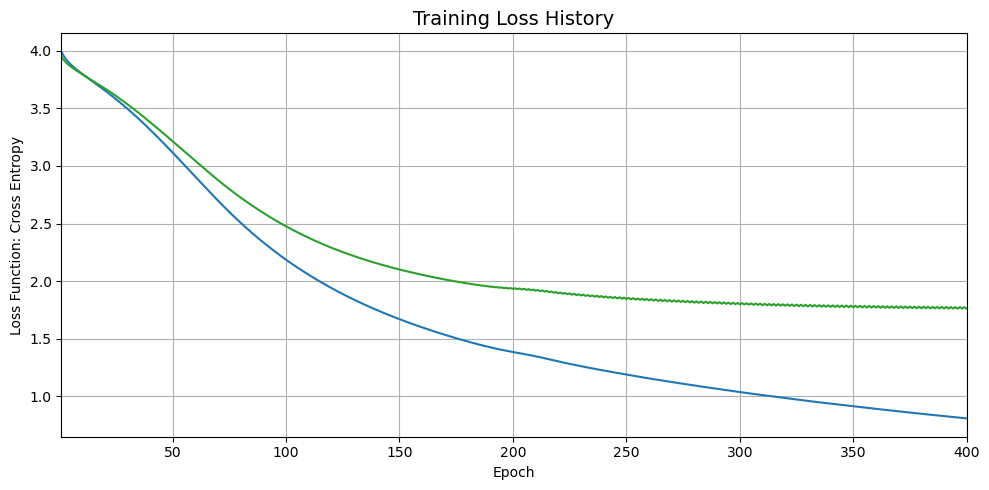

In [25]:
loss_history(output)

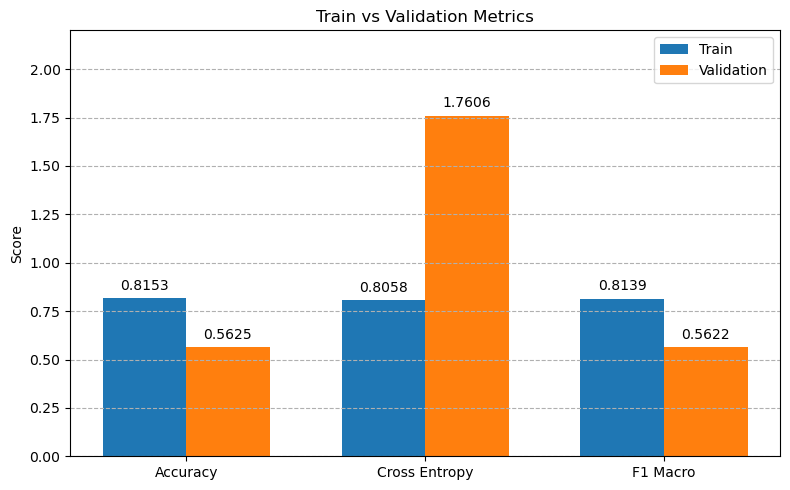

In [26]:
compare_metrics(MLP1, X_train, y_train, X_val, y_val)

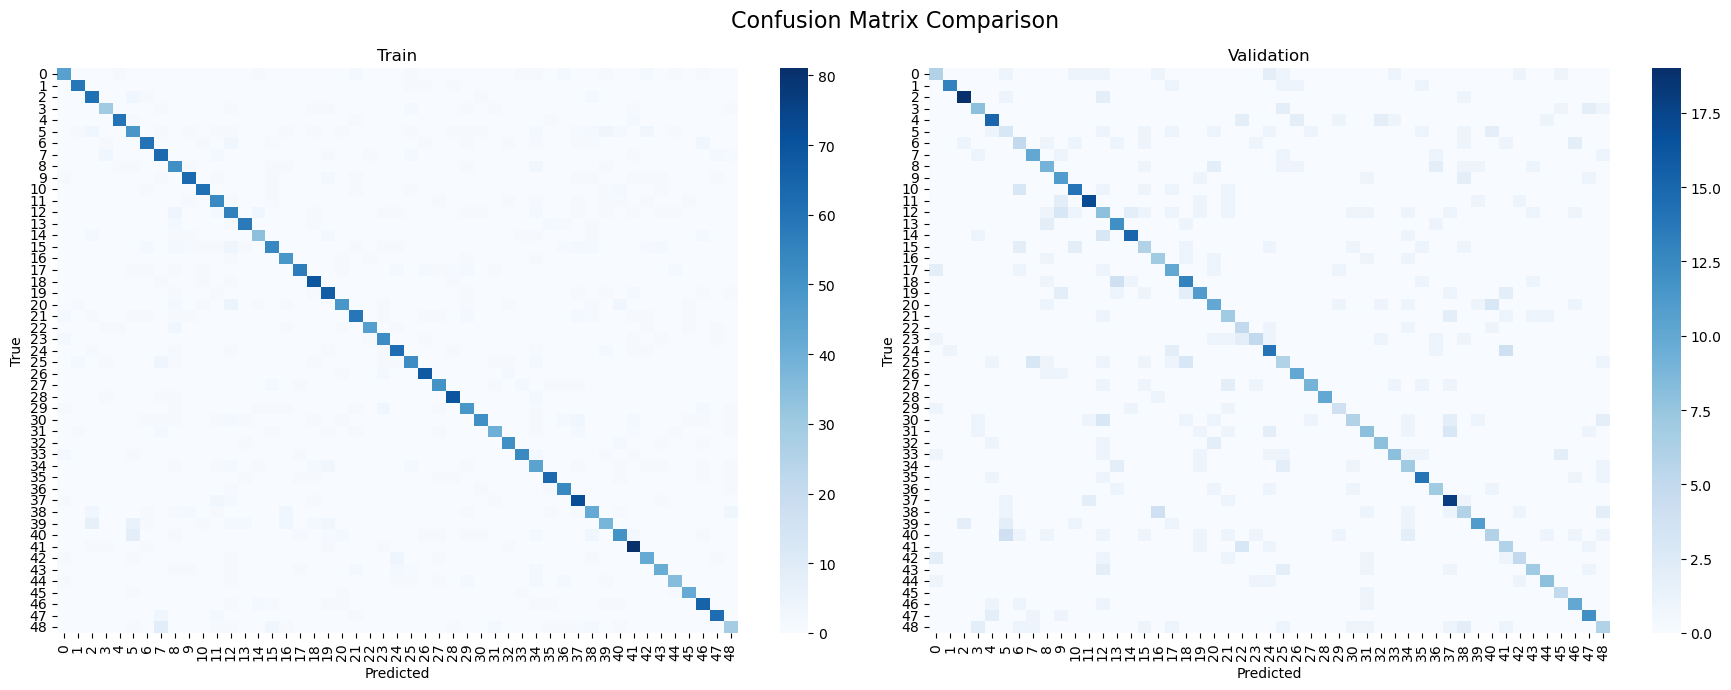

In [27]:
compare_confusion_matrix(MLP1, X_train, y_train, X_val, y_val)